mix them pixels yooo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import linear_mixing as lmx
import ternary
import scipy.stats as stats
from scipy.optimize import curve_fit

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

# other plotting

In [3]:
data = pd.read_csv("classification_results.csv")

In [4]:
data.head()

,Sensor,Scheme,f1-score
0,ASD,genus,0.7910
1,ASD,kelp_det,0.8840
2,ASD,BAM,0.7449
3,ASD,KBAM,0.8585
4,ASD,KBRGM,0.8306


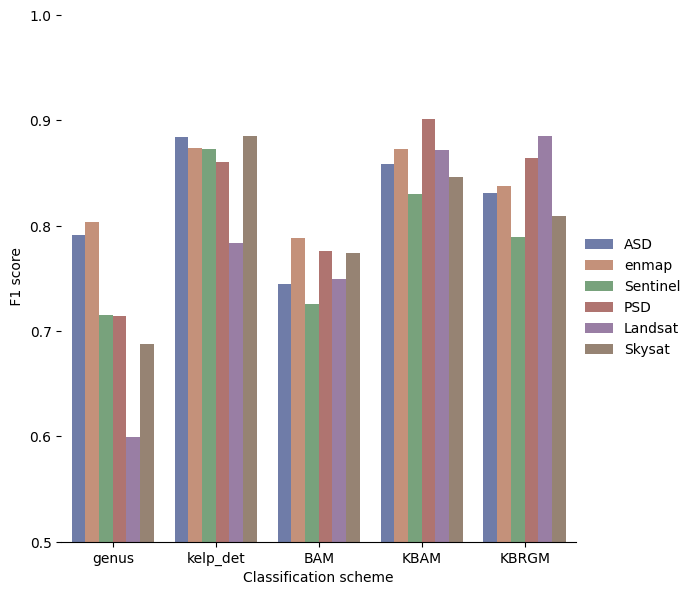

In [5]:
g = sns.catplot(
    data=data, kind="bar",
    x="Scheme", y="f1-score", hue="Sensor", 
    palette="dark", alpha=.6, height=6,
)
g.despine(left=True)
g.set(ylim = (0.5, 1))
g.set_axis_labels("Classification scheme", " F1 score")
g.legend.set_title("")
g.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\class_sensor_scores.svg")

# mixing pixels

In [6]:
material_options = {
    "kelp" : ['ecklonia', 'macrocystis', 'undaria'],
    # "brown_algae" : ['ecklonia', 'macrocystis', 'petalonia', 
    #                  'undaria','acrocarpia', 'cystophora', 'carpophyllum', 'durvillaea', 'hormosira', 'phyllospora', 'sargassum', 'scytosiphon'], 
    #"brown_non_kelp" : ['acrocarpia', 'cystophora', 'carpophyllum', 
    #                     'durvillaea', 'hormosira', 'petalonia','phyllospora', #'sargassum', 'scytosiphon'],
    #"red_veg" : ['rhodophyte', 'filamentous_rhodophyte','frondose_rhodophyte',],
    #"green_veg" : ['grass', 'ulva'],
    # "non_brown_autos" : ['grass', 'filamentous_rhodophyte',
    #                      'frondose_rhodophyte', 'rhodophyte', 'ulva'],
    # "all_non_kelp_autos" : ['acrocarpia', 'carpophyllum', 'cystophora', 
    #                         'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'petalonia', 'grass','hormosira','phyllospora', 'rhodophyte',  'sargassum','scytosiphon','ulva'],
    # "all_non_kelp" : ['acrocarpia', 'barnacle_shells', 'carpophyllum',
    #                   'cystophora', 'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'gravel', 'grass','hormosira','mussels','petalonia','phyllospora', 'rhodophyte', 'rock','sand', 'sargassum', 'scytosiphon', 'shell_litter','rock', 'ulva', 'worm_castings'],
    "mineral" : ['barnacle_shells', 'gravel', 'mussels', 'rock', 'sand', 
                  'shell_litter', 'worm_castings'],
    }
material_options.keys()

dict_keys(['kelp', 'mineral'])

In [7]:
#Assign fractional cover ranges with simulate within
cover_ranges = {
    "kelp" : (0,0.8),
    #"brown_algae" : (0, 0.5), 
    "brown_non_kelp" : (0,0.8),
    "red_veg" : (0,0.2),
    "green_veg" : (0, 0.5),
    #"non_brown_autos" : (0, 40),
    #"all_non_kelp_autos" : (0, 100),
    #"all_non_kelp" : (0,100),
    "mineral" : (0,0.7),}

In [8]:
data = pd.read_csv("./data/processed/resampled/noisy_Sentinel_2_ABC_resampled.csv", index_col=0)
labels = pd.read_csv("data/labels_prepped.csv", index_col=0)
data = pd.concat([labels["Class"], data], axis = 1)

In [9]:
waters = pd.read_csv("./S2_deep_water_agg.csv", index_col=0)
waters = waters.iloc[:, 4:-3]
print(f"total of {waters.shape[0]} water pixels loaded")
waters.drop_duplicates(inplace = True)
print(f"Total of {waters.shape[0]} unique water pixels kept")
waters= waters/10000
waters.head()


total of 400637 water pixels loaded
Total of 393022 unique water pixels kept


,nbart_blue,nbart_green,nbart_red,nbart_red_edge_1,nbart_red_edge_2,nbart_red_edge_3,nbart_nir_1,nbart_nir_2
1,0.0323,0.0327,0.0163,0.0168,0.0187,0.0195,0.0203,0.0198
2,0.0327,0.0303,0.0162,0.0177,0.0199,0.0210,0.0182,0.0217
3,0.0309,0.0310,0.0174,0.0177,0.0199,0.0210,0.0193,0.0217
4,0.0316,0.0329,0.0181,0.0192,0.0195,0.0211,0.0192,0.0208
6,0.0344,0.0319,0.0200,0.0192,0.0195,0.0211,0.0218,0.0208


In [10]:
mixer = lmx.LinearMixing(materials = material_options, cover_ranges = cover_ranges, pixels = 40000, material_spectra= data, water_spectra = waters)


In [11]:
results, f = mixer.sim_many_pixels()

In [12]:
simulated_pixels, pixel_fpcs = mixer.format_sim_results(results, f)
simulated_pixels.head()

,S2A_SR_AV_B2,S2A_SR_AV_B3,S2A_SR_AV_B4,S2A_SR_AV_B5,S2A_SR_AV_B6,S2A_SR_AV_B7,S2A_SR_AV_B8,S2A_SR_AV_B8A
0,0.031200,0.023900,0.010300,0.008500,0.006600,0.008600,0.006300,0.005400
1,0.024080,0.077890,0.048150,0.320260,0.699315,0.746312,0.760014,0.763617
2,0.354365,0.488325,0.548775,0.547685,0.516016,0.449908,0.274587,0.156663
3,0.029995,0.042322,0.024939,0.096316,0.150717,0.157827,0.167049,0.171733
4,0.158909,0.272920,0.264714,0.466754,0.571457,0.546773,0.470707,0.410534


In [13]:
pixel_fpcs.head()

,kelp,mineral,water,non-water_comps
0,0.000000,0.000000,1.000000,0
1,0.660963,0.117574,0.221463,2
2,0.000000,0.629901,0.370099,1
3,0.135041,0.041938,0.823021,2
4,0.380426,0.220454,0.399120,2


# PCA Decomposition - endmembers

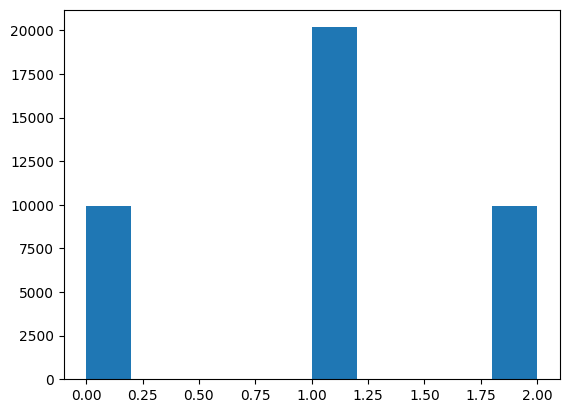

In [14]:
plt.hist(pixel_fpcs['non-water_comps'])
# fig.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\simulated_pixel_component_counts.svg")
plt.show()

In [15]:
#simulated_pixels.to_csv("data/mixed_sims/kbrgm_simulated_pixels_18112025.csv")
# pixel_fpcs.to_csv("data/mixed_sims/kbrgm_pixel_fpcs_18112025.csv")

In [16]:
#decide what you're simulating
label_level = "kom"
keep_list = ["kelp", "water", "mineral"]

# Add water to classifier training set 
sample_idx = np.random.choice(waters.index, size = 100, replace = False)
water_labels = pd.DataFrame("water", index = sample_idx, columns = labels.columns)
water_sample = waters.iloc[sample_idx, :]
water_sample.columns = data.columns[1:]
data_watered = pd.concat([data, water_sample], axis = 0)
labels_watered = pd.concat([labels, water_labels], axis = 0).set_index(data_watered.index)
data_watered = pd.concat([labels_watered, data_watered.iloc[:, 1:]], axis = 1)


In [17]:
# Filter training data to only mixed pixel components
data_watered = data_watered[data_watered[label_level].isin(keep_list)]

In [18]:
# Extract PCA components and transform dataset
deco = PCA(8)
deco.fit(data_watered.iloc[:,8:])
decomposed_train = deco.transform(data_watered.iloc[:, 8:])
decomposed_test = deco.transform(simulated_pixels)
comps = deco.components_

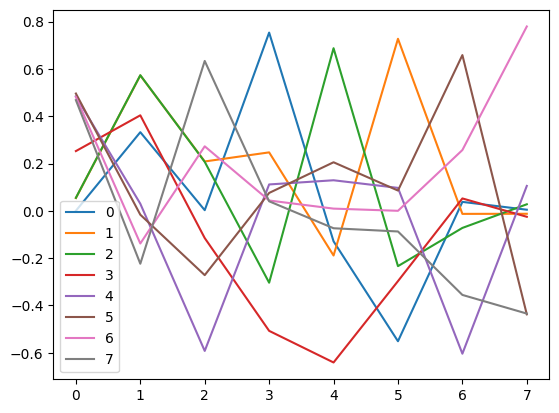

In [19]:
plt.plot(comps, label = range(comps.shape[1]))
plt.legend()
plt.show()

# RFC trained on endmembers

In [20]:
classer = RandomForestClassifier(random_state=4, oob_score= True, n_estimators=1000)
# classer.fit(data_watered.iloc[:, 1:], labels_watered["kbrgm"])
classer.fit(decomposed_train, data_watered["kom"])

RandomForestClassifier(n_estimators=1000, oob_score=True, random_state=4)

In [21]:
# Inspect random forest outputs
print(classer.oob_score_)
print(classer.feature_importances_)

1.0
[0.33304593 0.21789113 0.12265045 0.11157664 0.08842531 0.07111386
 0.04872512 0.00657157]


In [22]:
g = pd.DataFrame(classer.predict_proba(decomposed_test))
# g.to_csv("kbrgm_simulated_pixel_class_probs.csv")

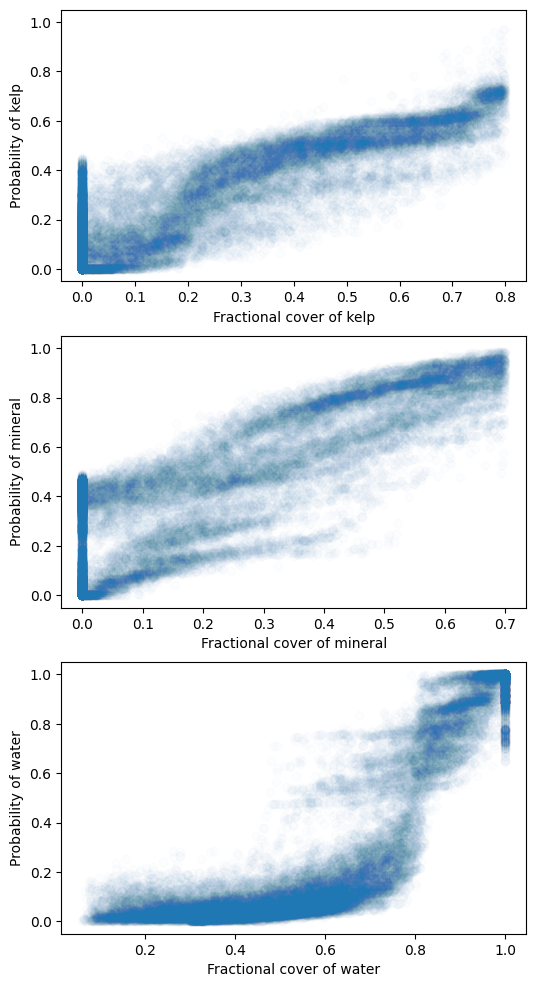

In [23]:
# Plot all prediction results
fig, axes = plt.subplots(len(pixel_fpcs.columns[:-1]), 1, sharey = True, figsize = (6,12))
for column in range(len(pixel_fpcs.columns[:-1])):
    material = pixel_fpcs.columns[column]
    axes[column].scatter(pixel_fpcs[material], g[column], alpha = 0.01)
    axes[column].set_ylabel(f"Probability of {material}")
    axes[column].set_xlabel(f"Fractional cover of {material}")


In [24]:
slope, intercept, r_value, p_value, std_err = stats.linregress(pixel_fpcs["water"], g[2])
print(f"Kelp cover vs predicted kelp prob: R2 = {r_value**2}, p = {p_value}.")
print(f"Kelp actual fractional cover to prediction: slope= {slope}, intercept = {intercept}.")

Kelp cover vs predicted kelp prob: R2 = 0.8317473612215651, p = 0.0.
Kelp actual fractional cover to prediction: slope= 1.3492973984909225, intercept = -0.455783132295861.


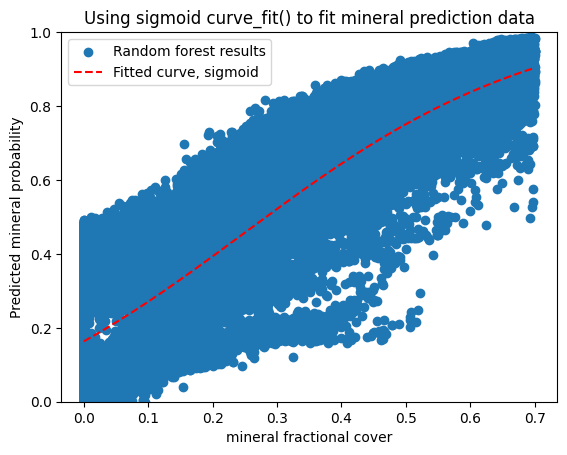

In [25]:
# Assign x and y variables once
mat = "mineral"
x = pixel_fpcs[mat]
y = g[1]+0.0000000001


# sigmoid calculation
def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return (y)


p0 = [max(y), np.mean(x), 1, 0] # this is an mandatory initial guess

popt, pcov = curve_fit(sigmoid, x, y, p0, method='trf')
#popt[3] = 0
x_fitted_weighted = np.linspace(np.min(x), np.max(x), 500)
y_fitted_sigmoid = sigmoid(x_fitted_weighted, *popt)


# Plot
ax = plt.axes()
ax.scatter(x, y, label='Random forest results')
ax.plot(x_fitted_weighted, y_fitted_sigmoid, '--', color = "red", label='Fitted curve, sigmoid')
ax.set_title(f'Using sigmoid curve_fit() to fit {mat} prediction data')
ax.set_ylabel(f'Predicted {mat} probability')
ax.set_ylim(0, 1)
ax.set_xlabel(f'{mat} fractional cover')
ax.legend()

In [26]:
# Access sigmoid function parameters
popt

array([ 1.19042131,  0.24877685,  4.32652756, -0.13915799])

In [27]:
ssregression = []
sst = []
mean = np.mean(g[2])
for f in g[2]:
    pred_f = sigmoid(f, *popt)
    diff = (f - pred_f)**2
    ssregression.append(diff)
    sst.append((f-mean)**2)

ssregression = np.sum(ssregression)
sst = np.sum(sst)

r_s = 1- (ssregression/sst)
print(f" R squared is equal to {r_s}")


 R squared is equal to 0.8724368241295166


Text(0.5, 0, 'Probability of mineral')

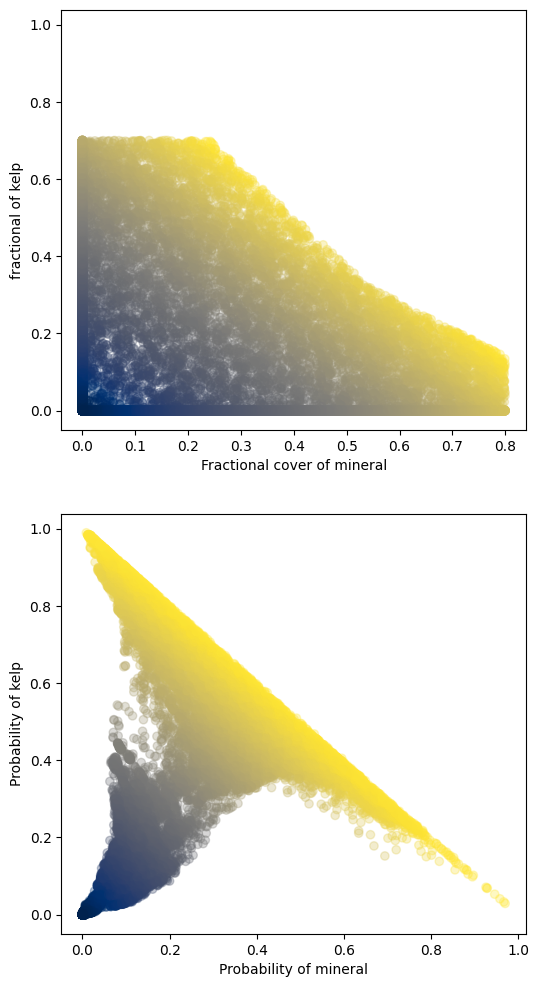

In [28]:
# Plotting kelp by mineral, prediction and FPC

fig, axes = plt.subplots(2,  1, sharey = True, figsize = (6,12))
axes[0].scatter(pixel_fpcs["kelp"], pixel_fpcs["mineral"], c = pixel_fpcs["water"], cmap = "cividis_r", alpha = 0.3)
axes[0].set_ylabel(f"fractional of kelp")
axes[0].set_xlabel(f"Fractional cover of mineral")
axes[1].scatter(g[0], g[1], c = g[2], cmap = "cividis_r", alpha = 0.3)
axes[1].set_ylabel(f"Probability of kelp")
axes[1].set_xlabel(f"Probability of mineral")


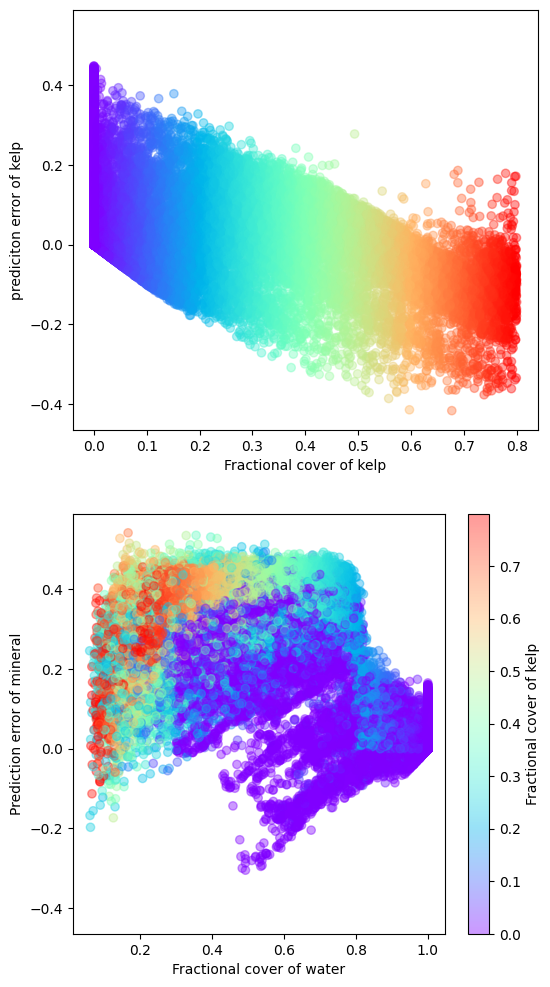

In [29]:
# Plotting prediction error by FPC

fig, axes = plt.subplots(2,  1, sharey = True, figsize = (6,12))
axes[0].scatter(pixel_fpcs["kelp"], g[0] - pixel_fpcs['kelp'], c = pixel_fpcs["kelp"], cmap = "rainbow", alpha = 0.4)
axes[0].set_ylabel(f"prediciton error of kelp")
axes[0].set_xlabel(f"Fractional cover of kelp")
axes[1].scatter(pixel_fpcs["water"], g[1]- pixel_fpcs['mineral'], c = pixel_fpcs["kelp"], cmap = "rainbow", alpha = 0.4)
axes[1].set_ylabel(f"Prediction error of mineral")
axes[1].set_xlabel(f"Fractional cover of water")
fig.colorbar(axes[1].collections[0], ax=axes[1], label='Fractional cover of kelp')


C:\Users\s4770224\AppData\Local\Temp\ipykernel_14476\1950573016.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


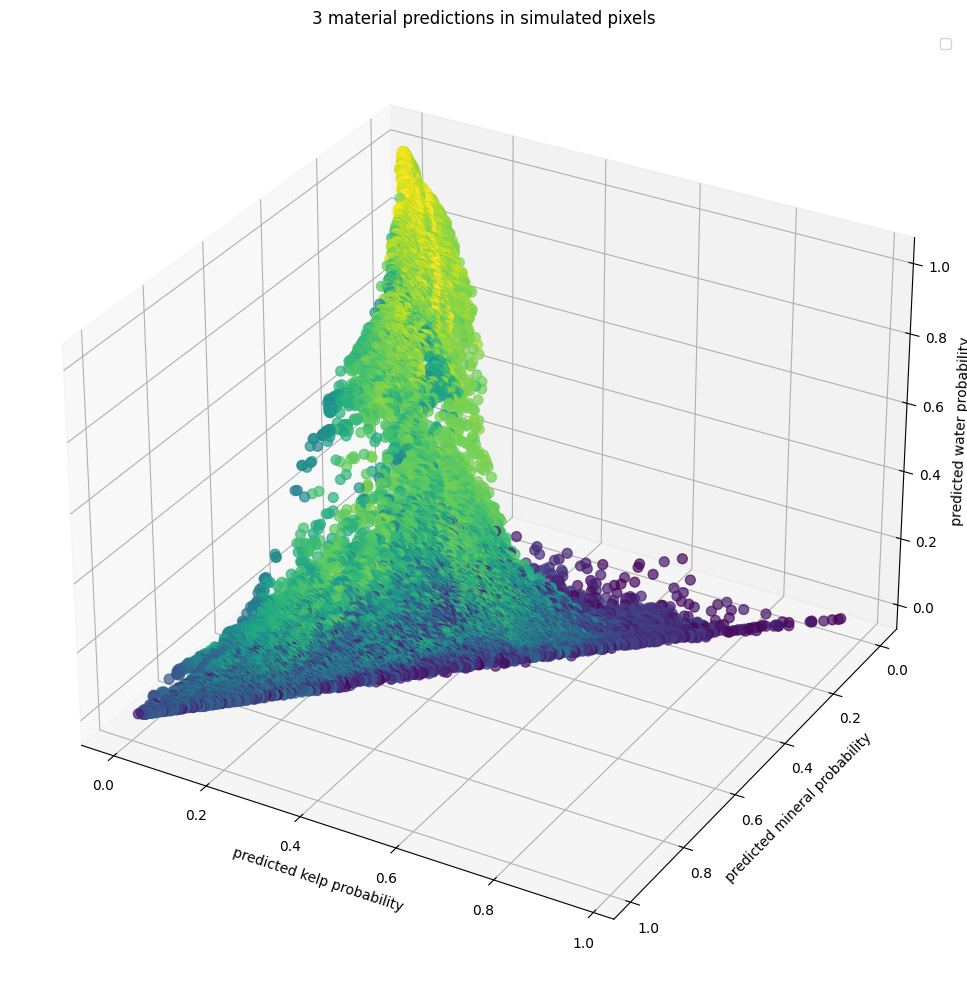

In [30]:
# 3D predicition plot

components = [0,1,2]

# Plot 3-way predictions 
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(projection='3d')
x, y, z = components

ax.scatter(g[x], g[y], g[z], c=pixel_fpcs["water"], cmap = "viridis", alpha=0.7, s=50)
ax.yaxis.set_inverted(True)
plt.xlabel('predicted kelp probability')
plt.ylabel('predicted mineral probability')
if len(components) == 3:
    ax.set_zlabel('predicted water probability')
plt.title('3 material predictions in simulated pixels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# # Ternary plot - UNFINISHED/INCORRECT

# # Format data for ternary plot
# points = []
# for row in range(g.shape[0]):
#     x,y,z = g.iloc[row, 0], g.iloc[row, 1], g.iloc[row, 2]
#     points.append((x,y,z))
    
# points_dict = {}
# for x,y,z in points:
#     points_dict[(x,y)] = z

# # Create the figure
# fig, ax = plt.subplots(figsize=(10, 8))
# fig.patch.set_facecolor('white')

# # Create ternary axes (scale=1 for proportions, scale=100 for percentages)
# tax = ternary.TernaryAxesSubplot(ax=ax, scale=1.0)

# # Set labels for each vertex
# tax.set_title("Simple Ternary Plot", fontsize=16, pad=20)
# tax.left_axis_label("Predicted Water", fontsize=12, offset=0.15)
# tax.right_axis_label("Predicted Mineral", fontsize=12, offset=0.15)
# tax.bottom_axis_label("Predicted Kelp", fontsize=12, offset=0.15)

# # Draw boundary and gridlines
# tax.boundary(linewidth=1.5)
# tax.gridlines(multiple=0.1, color="gray", linewidth=0.5, alpha=0.5)

# # Plot the data points
# count = 0
# for point in points:
#     tax.scatter([point], marker='o', s=100, c=pixel_fpcs["water"][count], cmap = "viridis", alpha=0.7)
#     count +=1

# # Clear matplotlib axes
# tax.clear_matplotlib_ticks()
# tax.get_axes().axis('off')
# tax.ticks(axis='lbr', linewidth=1, multiple=0.1, offset=0.02)

# # Display the plot
# plt.tight_layout()
# plt.show()



KeyboardInterrupt: 

# RFC trained on mixpix  

In [32]:
sim_x_train, sim_x_test, sim_y_train, sim_y_test = train_test_split(simulated_pixels, pixel_fpcs, test_size=0.5, random_state=42)

## PCA on mixpix

In [33]:
# Extract PCA components and transform dataset
deco = PCA(8)
deco.fit(sim_x_train)
sim_decomp_train = deco.transform(sim_x_train)
sim_decomp_test = deco.transform(sim_x_test)

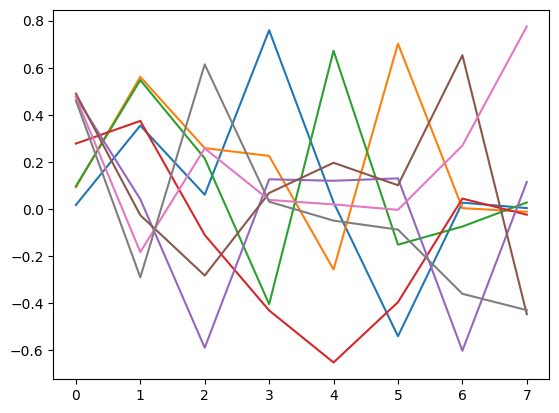

In [34]:
# Plot components
plt.plot(deco.components_)
plt.xlabel("Spectral band")
plt.ylabel("PCA component weight")
plt.show()

## Mixpix Regressions

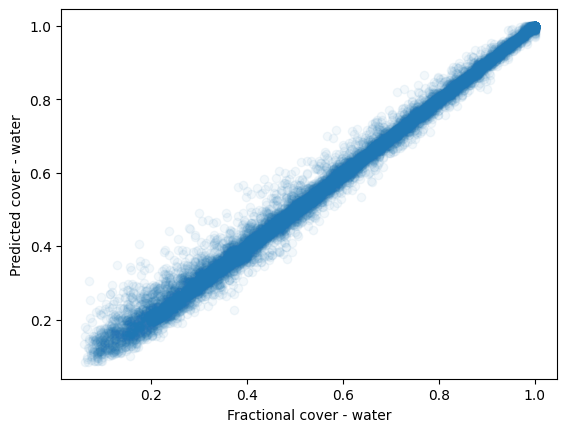

In [35]:
# Water probability classifier
water_cla = RandomForestRegressor(n_estimators = 100)
water_cla.fit(sim_decomp_train, sim_y_train["water"])

# predict on test data
water_pred = water_cla.predict(sim_decomp_test)

# Plot prediction results
plt.scatter(sim_y_test["water"], water_pred, alpha = 0.05)
plt.xlabel('Fractional cover - water')
plt.ylabel('Predicted cover - water')
plt.show()


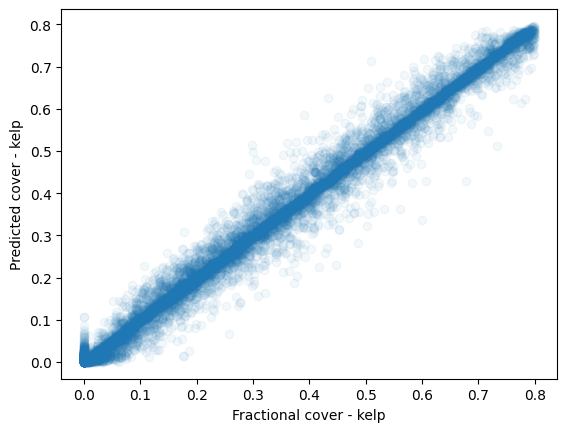

In [36]:
# kelp probability regressor
kelp_cla = RandomForestRegressor(n_estimators = 100)
kelp_cla.fit(sim_decomp_train, sim_y_train["kelp"])
# predict on test data
kelp_pred = kelp_cla.predict(sim_decomp_test)

# Plot prediction results
plt.scatter(sim_y_test["kelp"], kelp_pred, alpha = 0.05)
plt.xlabel('Fractional cover - kelp')
plt.ylabel('Predicted cover - kelp')
plt.show()

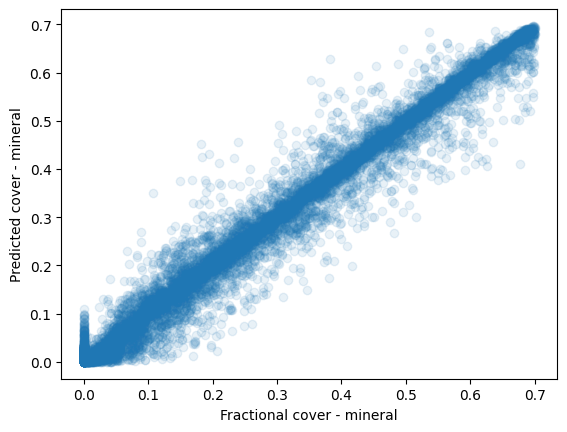

In [37]:
# mineral probability regressor
mineral_cla = RandomForestRegressor(n_estimators = 100)
mineral_cla.fit(sim_decomp_train, sim_y_train["mineral"])
# predict on test data
mineral_pred = mineral_cla.predict(sim_decomp_test)

# Plot prediction results
plt.scatter(sim_y_test["mineral"], mineral_pred, alpha = 0.1)
plt.xlabel('Fractional cover - mineral')
plt.ylabel('Predicted cover - mineral')
plt.show()

In [38]:
fpc = np.sum([water_pred, kelp_pred, mineral_pred], axis = 0)

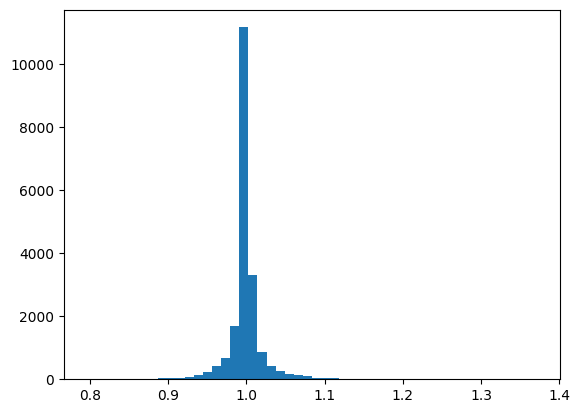

In [39]:
plt.hist(fpc, bins = 50)
plt.show()